> Random Variable

> Random variable is a variable that takes values that appear to be random in nature 

> Ne geleneksel yazilim anlamda degiskendir, ne de rastgeledir

> Gercek dunyadaki fiziksel veya soyut olaylarin (ciktilarin) her birini sayisal bir degere donusturen matematiksel fonksiyondur


**Random variable : Olasi tum fiziksel/soyut sonuclarin kumesi (orneklem uzayi) => Reel sayilar**

#Sistemin guvenilirlik maliyetini hesaplamak icin 200 0k, 404 not found, 500 internal server error, 
bunlarin string degerlerinin ortalamasini veya varyansini alamazsiniz. Burada bir x random variable tanimlariz ve her olaya sisteme verdigi maliyet acisindan sayisal bir ceza puani atariz

x(200 Ok) = 0
x(404notfound) = 5
x(500 internal server errro) = 100

Artik elimizde soyut loglar degil, Expected value ve varyans hesaplayabileceginiz, olasilik dagilimina oturtabilecegim sayisal bir altyapi var

In [ ]:
# Continous Random Variable 
# float ==> continous
# belirli bir aralikta sonsuz sayida (kusuratli) deger alabilen variable
# PDF => Probabiliy Density Function ile modellenir
# Bir API-nin yanit suresi 124.54, server CPU sicakligi 72.1

In [ ]:
# Discrete Random Variable 
# integer ==> discrete - yalnizca belirli sayilabilir (tam sayi) degerler alabilen degiskenler.
# PMF => Probability Mass Function ile modellenir
#  Arada kusuratli deger almaz. PMF ile modellenir. Bir db-deki active connection sayisi, saniyedeki hata logu sayisi
# genre (comedy, action ...) ==> discrete


# CDF => Cumilative Distributino Funciton == summurization of all distribution function

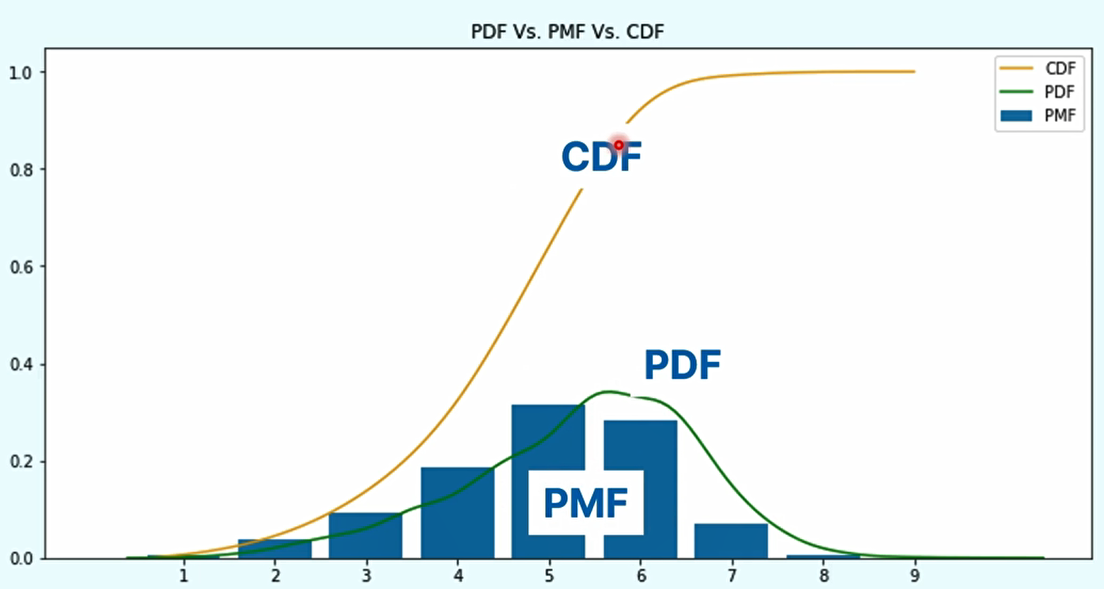

In [ ]:
# soyut bir olayi sayiya atarken baglami kaybedebilir. Yukarikdai API orneginde 404 hatasina 5 puan ceza verildi.
# Ancak her 404 error ayni oneme sahip degil. yani kritik bir endpoint 404 vermesi ile statik bir resimin 404 vermesi ayni degil
# Random variable bunu tek basina yapamiyor

#! Discrete random variabley continous bir variable gibi modele (Linear Reg) verilse model size ortalama 2.4 kullanici
# clickledi gibi anlamsiz ve mantiksiz error cevap verir. o yuzden kavramsal sinirlarin dogru cizilmesi cok onemli

In [ ]:
# Olaylari sayialara donusturerek  olasilik teorisinin (Beklenen deger, Varyans, standart sapma) tum analitik gucunu
# kullanmanizi saglar


In [202]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt


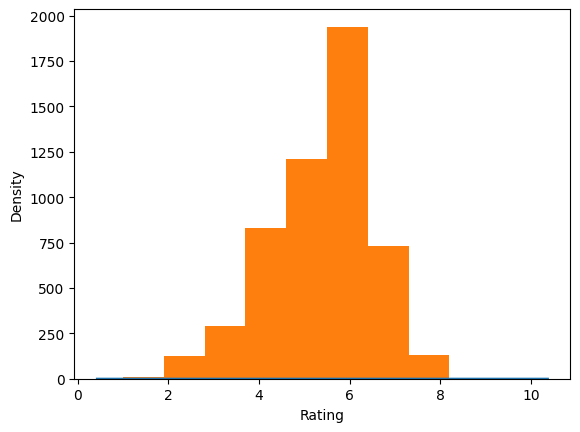

In [199]:
movies = pd.read_csv('../data_analysis/sources/Movies.csv')

discrete_rate = movies.Rating.apply(lambda x: round(x)) # ==> convert continous to discrete


# plt.hist(movies.Rating);
# sn.histplot(movies.Rating); # ===> histogram
# plt.boxplot(movies.Rating); # ==> boxplot
# sn.displot(movies.Rating)
sn.kdeplot(movies.Rating);   # ====> density plot

plt.hist(discrete_rate);

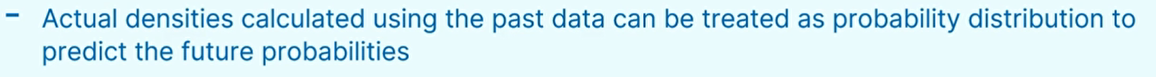

In [ ]:
# Distribution Functions

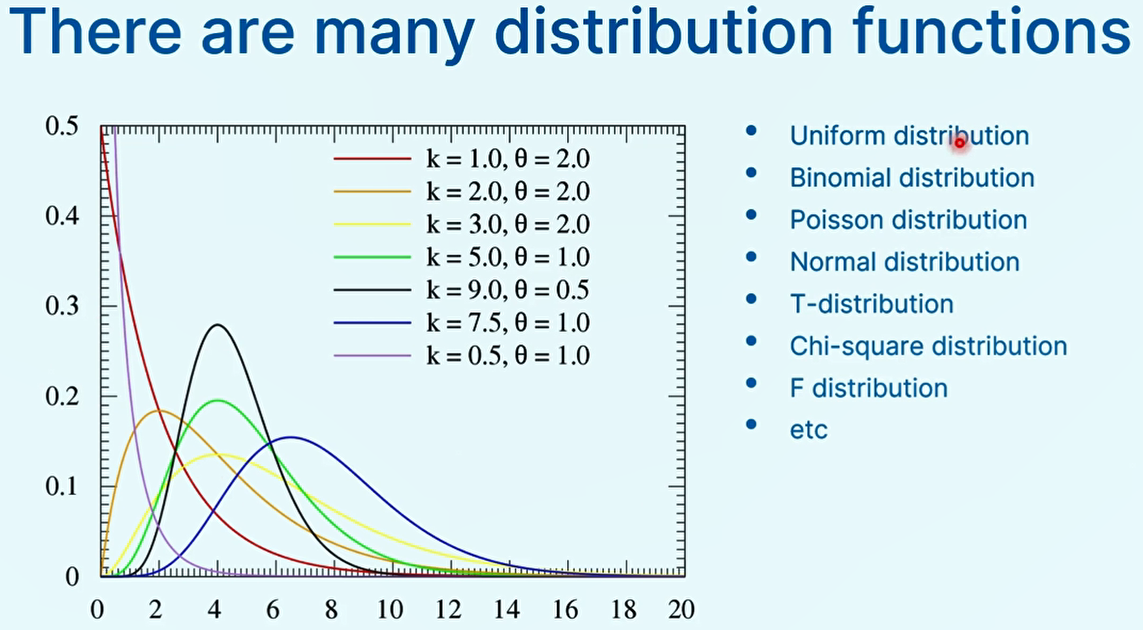

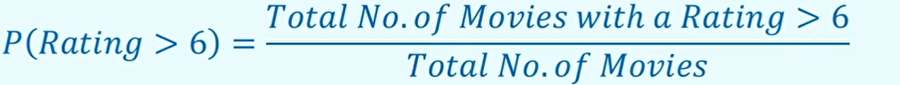

In [ ]:
rating_above_6 = (movies.Rating > 6).sum()
# print(rating_above_6)
p_rating_above_6 = rating_above_6 / len(movies.Rating)
p_rating_above_6 * 100

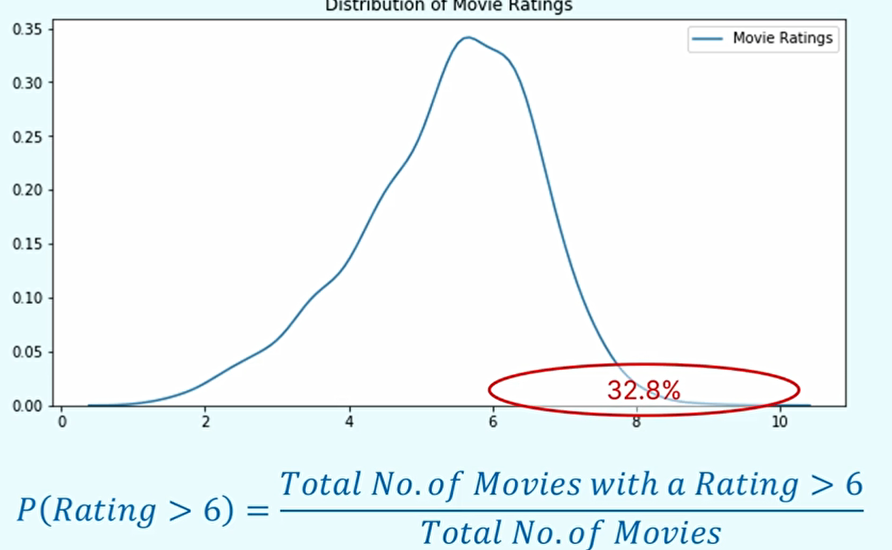

In [ ]:
movies.Rating.std()

In [ ]:
movies.Rating.mean()

In [ ]:
import scipy.stats as ss
values = ss.norm.rvs(loc=movies.Rating.mean(), scale=movies.Rating.std(), size = 10000, random_state=1)


In [ ]:
(values > 6).sum()  / len(values) * 100

In [ ]:
sn.kdeplot(movies.Rating);
sn.kdeplot(values);

In [ ]:
#Normal distribution ==> mean - median - mode all the same

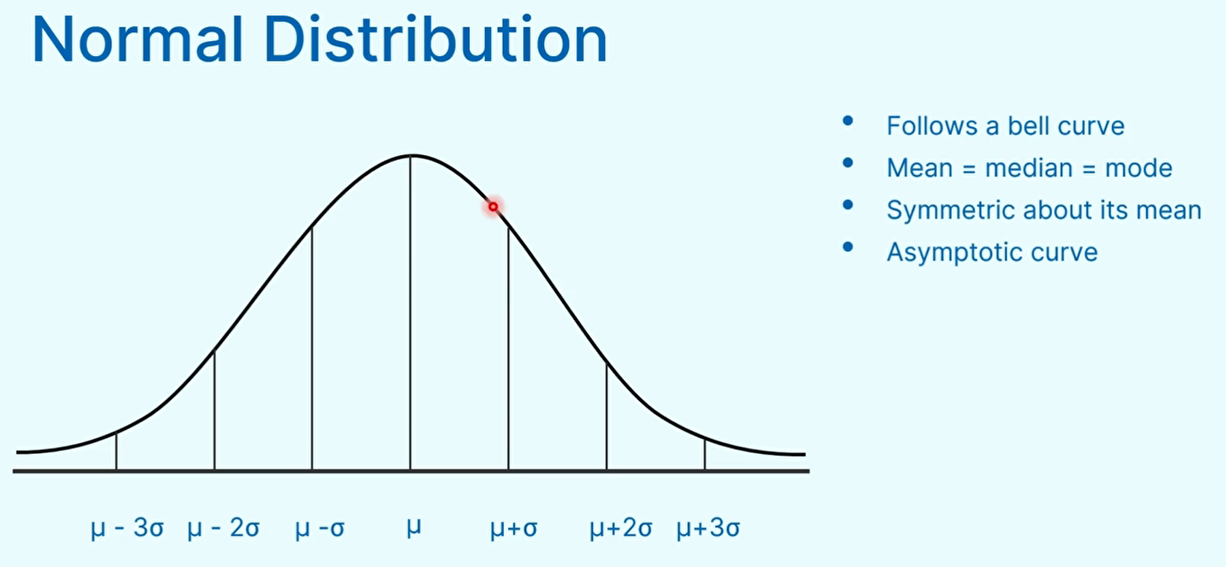

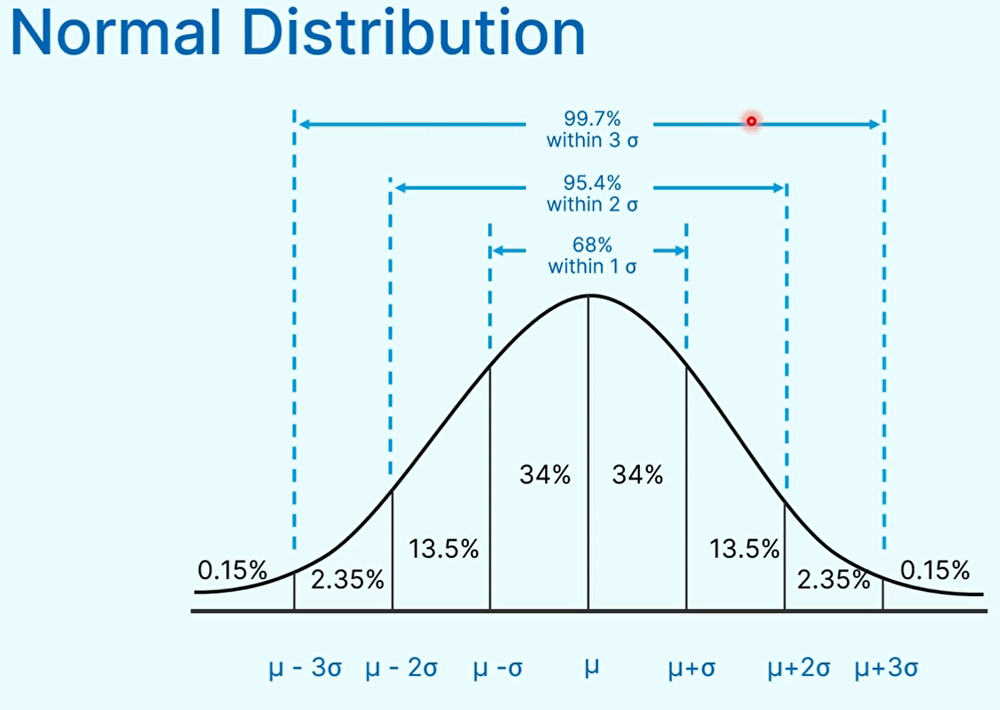

In [ ]:
# 99.7
# 95.4
# 68

In [ ]:
x = np.arange(-4, 4, 0.001)
z = (x - x.mean()) / x.std()
plt.plot(z);

In [ ]:
y_pdf = []
y_cdf = []

In [ ]:
for i in x:
    print(i)
    y_pdf.append(ss.norm.pdf(i, 0, 1))
    y_cdf.append(ss.norm.cdf(i, 0, 1))

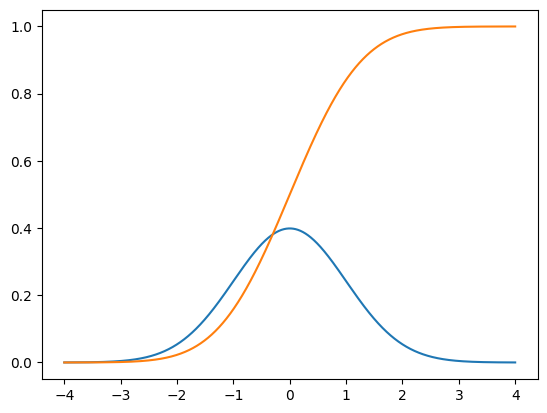

In [195]:
plt.plot(x, y_pdf)
plt.plot(x, y_cdf)

In [ ]:
ss.norm.cdf(1,0,1) - ss.norm.cdf(-1,0,1)
ss.norm.cdf(2,0,1) - ss.norm.cdf(-2,0,1)
ss.norm.cdf(3,0,1) - ss.norm.cdf(-3,0,1)

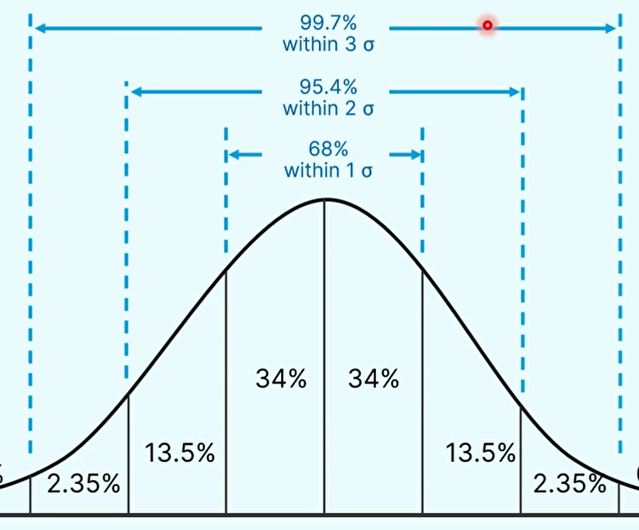

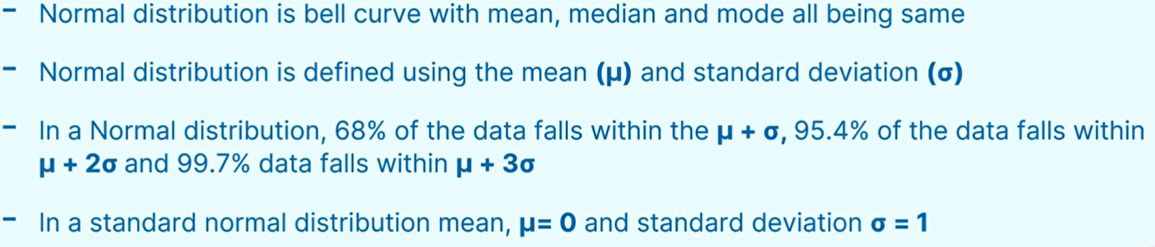

In [ ]:
# Practice

(movies.Rating == 6).sum() / len(movies.Rating) * 100

In [ ]:
(movies.Rating == 7).sum() / len(movies.Rating) * 100

In [ ]:
(movies.Rating == 8).sum() / len(movies.Rating) * 100 

In [ ]:
(movies.Rating > 8).sum() / len(movies.Rating) * 100  # there is 0.53 chance to get the less than 8 

In [ ]:
(1 - ss.norm.cdf(x=6, loc=movies.Rating.mean(), scale=movies.Rating.std())) * 100 #==> 0.309 change to get 6 rate

In [ ]:
(1- ss.norm.cdf(x=7, loc=movies.Rating.mean(), scale=movies.Rating.std())) * 100  #==> 0.097 change to get 7 rate

In [ ]:
(1 - ss.norm.cdf(x=8, loc=movies.Rating.mean(), scale=movies.Rating.std())) * 100 #==> 0.017 change to get 8 rate

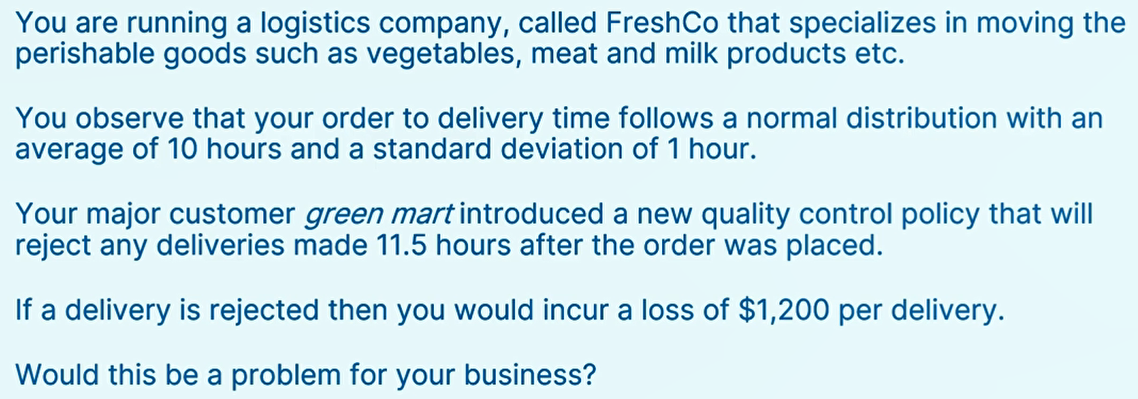

In [ ]:
ss.norm.cdf(x=11.5*60, loc=10*60, scale=60)

In [ ]:
1 - ss.norm.cdf(x=11.5*60, loc=10*60, scale=60)

In [ ]:
(1-ss.norm.cdf(x=11.5*60, loc=10*60, scale=60)) * 1200 # ==> average loss